In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ot
import pandas as pd
import time
import random
from gwgraphs import *
from scipy.stats import ttest_ind

In [2]:
# Create Graph Data #
np.random.seed(42)
random.seed(42)

In [3]:
# Generate ERSBM1
prob_matrix = [
    [0.15, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.15]  # Probabilities related to block 2 connections
]

graphs_er = generate_erdos_renyi_graphs(100, 100, 0.1)
graphs_sbm = generate_sbm_graphs(100, [50, 50], prob_matrix)

full_graph_data = graphs_er + graphs_sbm
# Convert graphs to pairwise distance matrices
distance_matrices = [
    compute_distance_matrix(graph) for graph, label in full_graph_data
]
# Prepare labels
labels = [label for graph, label in full_graph_data]

# Normalize the matrices
Ms = []
for matrix in distance_matrices:
    Ms.append(matrix / np.max(matrix))

# Prepare labels
labels = [label for graph, label in full_graph_data]

In [4]:
# Generate ERSBM2
prob_matrix5 = [
    [0.45, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.45]  # Probabilities related to block 2 connections
]

graphs_er5 = generate_erdos_renyi_graphs(100, 100, 0.25)
graphs_sbm5 = generate_sbm_graphs(100, [50, 50], prob_matrix5)

full_graph_data5 = graphs_er5 + graphs_sbm5
# Convert graphs to pairwise distance matrices
distance_matrices5 = [
    compute_distance_matrix(graph) for graph, label in full_graph_data5
]

# Normalize the matrices
Ms5 = []
for matrix in distance_matrices5:
    Ms5.append(matrix / np.max(matrix))

# Prepare labels
labels5 = [label for graph, label in full_graph_data5]

In [5]:
# GW Distances Scatterplots - ERSBM1 #
# Normalize the matrices
N=200
heights = [
    np.full(len(graph), 1 / len(graph)) for graph, label in full_graph_data
]
gw = np.zeros((N,N))

# Track negative values during computation
negative_count = 0
negative_pairs = []

for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
        gw_value = tmp[0]
        gw[i,j] = gw_value
        
        # Check for negative values
        if gw_value < 0:
            negative_count += 1
            negative_pairs.append((i, j, gw_value))
            print(f"Negative GW distance found: graphs {i} and {j}, value: {gw_value}")
        
        # Check for NaN values
        if np.isnan(gw_value):
            print(f"NaN GW distance found: graphs {i} and {j}")
        
        #Ps_gw[i,j] = tmp[1]["T"]

print(f"\nGW computation summary (ERSBM1):")
print(f"Total negative values found: {negative_count}")
print(f"Min GW value: {np.min(gw[gw != 0])}")
print(f"Max GW value: {np.max(gw)}")
print(f"Number of NaN values: {np.sum(np.isnan(gw))}")

# Print first few negative pairs if any
if negative_pairs:
    print(f"\nFirst 5 negative pairs:")
    for i, (idx_i, idx_j, val) in enumerate(negative_pairs[:5]):
        print(f"  Pair {i+1}: graphs {idx_i} and {idx_j}, value: {val}")

# Handle negative values by taking absolute value before sqrt
gw_abs = np.abs(gw)
gw = np.sqrt(gw_abs)
gw += gw.T


GW computation summary (ERSBM1):
Total negative values found: 0
Min GW value: 0.021336000000000445
Max GW value: 0.11723199999999986
Number of NaN values: 0


In [6]:
# GW Distances Scatterplots - ERSBM2 # 
# Normalize the matrices
N=200
heights5 = [
    np.full(len(graph), 1 / len(graph)) for graph, label in full_graph_data5
]
gw5 = np.zeros((N,N))

# Track negative values during computation
negative_count5 = 0
negative_pairs5 = []

for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms5[i],Ms5[j],heights5[i],heights5[j],loss_fun="square_loss",log=True)
        gw_value = tmp[0]
        gw5[i,j] = gw_value
        
        # Check for negative values
        if gw_value < 0:
            negative_count5 += 1
            negative_pairs5.append((i, j, gw_value))
            print(f"Negative GW distance found: graphs {i} and {j}, value: {gw_value}")
        
        # Check for NaN values
        if np.isnan(gw_value):
            print(f"NaN GW distance found: graphs {i} and {j}")
        
        #Ps_gw[i,j] = tmp[1]["T"]

print(f"\nGW computation summary (ERSBM2):")
print(f"Total negative values found: {negative_count5}")
print(f"Min GW value: {np.min(gw5[gw5 != 0])}")
print(f"Max GW value: {np.max(gw5)}")
print(f"Number of NaN values: {np.sum(np.isnan(gw5))}")

# Print first few negative pairs if any
if negative_pairs5:
    print(f"\nFirst 5 negative pairs:")
    for i, (idx_i, idx_j, val) in enumerate(negative_pairs5[:5]):
        print(f"  Pair {i+1}: graphs {idx_i} and {idx_j}, value: {val}")

# Handle negative values by taking absolute value before sqrt
gw_abs5 = np.abs(gw5)
gw5 = np.sqrt(gw_abs5)
gw5 += gw5.T


GW computation summary (ERSBM2):
Total negative values found: 0
Min GW value: 0.028466666666666873
Max GW value: 0.1382555555555563
Number of NaN values: 0


In [28]:
# Create side-by-side scatterplots of GW distances by class (ERSBM1 & ERSBM2)
# Function to analyze GW distances for a dataset
def analyze_gw_distances(gw_matrix, labels_array, ax, title):
    # Get indices for each class
    class_1_indices = np.where(labels_array == 1)[0]  # ER class
    class_minus1_indices = np.where(labels_array == -1)[0]  # SBM class
    
    # Extract GW distances for different class combinations
    # Within class 1 (ER vs ER)
    within_class1_distances = []
    for i in range(len(class_1_indices)):
        for j in range(i+1, len(class_1_indices)):
            idx_i, idx_j = class_1_indices[i], class_1_indices[j]
            within_class1_distances.append(gw_matrix[idx_i, idx_j])
    
    # Within class -1 (SBM vs SBM)
    within_class_minus1_distances = []
    for i in range(len(class_minus1_indices)):
        for j in range(i+1, len(class_minus1_indices)):
            idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
            within_class_minus1_distances.append(gw_matrix[idx_i, idx_j])
    
    # Between classes (ER vs SBM)
    between_classes_distances = []
    for i in class_1_indices:
        for j in class_minus1_indices:
            between_classes_distances.append(gw_matrix[i, j])
    
    # Create scatter plot data
    x_positions = []
    distances = []
    colors = []
    
    # Add within class 1 distances
    x_positions.extend([0] * len(within_class1_distances))
    distances.extend(within_class1_distances)
    colors.extend(['blue'] * len(within_class1_distances))
    
    # Add within class -1 distances
    x_positions.extend([1] * len(within_class_minus1_distances))
    distances.extend(within_class_minus1_distances)
    colors.extend(['orange'] * len(within_class_minus1_distances))
    
    # Add between classes distances
    x_positions.extend([2] * len(between_classes_distances))
    distances.extend(between_classes_distances)
    colors.extend(['gray'] * len(between_classes_distances))
    
    # Create the scatter plot
    scatter = ax.scatter(x_positions, distances, c=colors, alpha=0.6, s=30)
    
    # Customize the plot
    ax.set_xlabel('Class Comparison')
    ax.set_ylabel('Gromov-Wasserstein Distance')
    ax.set_title(title)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['ER vs ER\n(Class 1)', 'SBM vs SBM\n(Class -1)', 'ER vs SBM\n(Cross-class)'])
    ax.grid(True, alpha=0.3)
    
    return within_class1_distances, within_class_minus1_distances, between_classes_distances

ERSBM1 Statistics:
Within ER class - Mean: 0.1811, Std: 0.0121
Within SBM class - Mean: 0.1833, Std: 0.0132
Between classes - Mean: 0.1824, Std: 0.0126

ERSBM2 Statistics:
Within ER class - Mean: 0.1800, Std: 0.0268
Within SBM class - Mean: 0.1848, Std: 0.0120
Between classes - Mean: 0.1958, Std: 0.0171


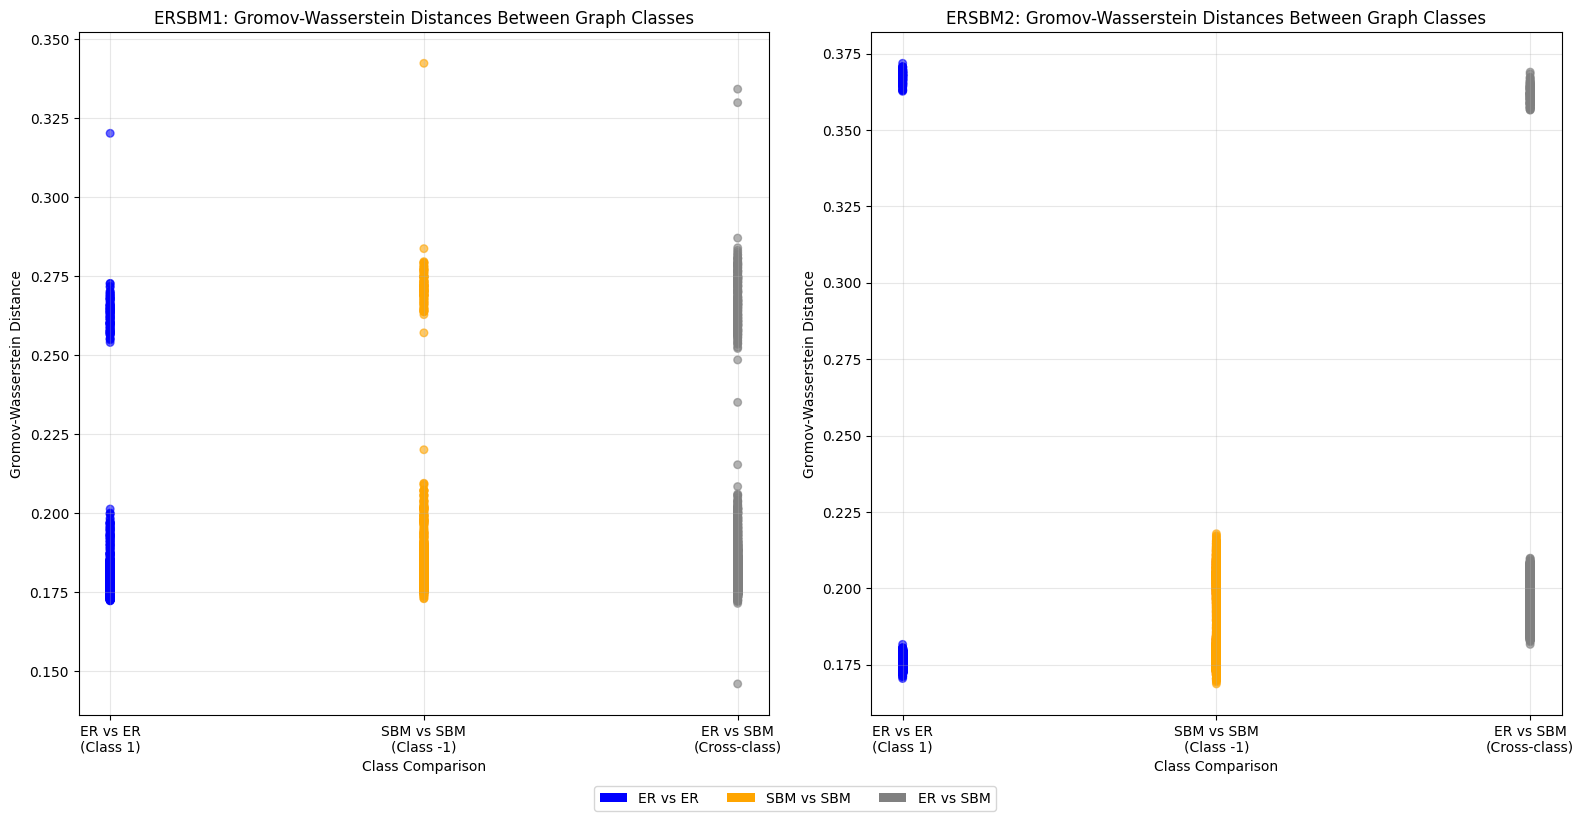

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Convert labels to numpy arrays for easier indexing
labels_array = np.array(labels)
labels5_array = np.array(labels5)

# Analyze ERSBM1
within_class1_dist1, within_class_minus1_dist1, between_classes_dist1 = analyze_gw_distances(
    gw, labels_array, ax1, 'ERSBM1: Gromov-Wasserstein Distances Between Graph Classes'
)

# Analyze ERSBM2
within_class1_dist2, within_class_minus1_dist2, between_classes_dist2 = analyze_gw_distances(
    gw5, labels5_array, ax2, 'ERSBM2: Gromov-Wasserstein Distances Between Graph Classes'
)

# Add legend to the figure
legend_elements = [Patch(facecolor='blue', label='ER vs ER'),
                   Patch(facecolor='orange', label='SBM vs SBM'),
                   Patch(facecolor='gray', label='ER vs SBM')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Print statistics for both datasets
print("="*60)
print("ERSBM1 Statistics:")
print(f"Within ER class - Mean: {np.mean(within_class1_dist1):.4f}, Std: {np.std(within_class1_dist1):.4f}")
print(f"Within SBM class - Mean: {np.mean(within_class_minus1_dist1):.4f}, Std: {np.std(within_class_minus1_dist1):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_dist1):.4f}, Std: {np.std(between_classes_dist1):.4f}")

print("\nERSBM2 Statistics:")
print(f"Within ER class - Mean: {np.mean(within_class1_dist2):.4f}, Std: {np.std(within_class1_dist2):.4f}")
print(f"Within SBM class - Mean: {np.mean(within_class_minus1_dist2):.4f}, Std: {np.std(within_class_minus1_dist2):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_dist2):.4f}, Std: {np.std(between_classes_dist2):.4f}")
print("="*60)

plt.show()

In [9]:
# Perform statistical tests for both ERSBM1 and ERSBM2
def perform_statistical_analysis(within_class1_dist, within_class_minus1_dist, between_classes_dist, 
                                labels_array, dataset_name):
    """Perform statistical analysis on GW distances for a dataset"""
    
    # Calculate means
    active_vs_inactive_mean = np.mean(between_classes_dist)
    within_active_mean = np.mean(within_class1_dist)
    within_inactive_mean = np.mean(within_class_minus1_dist)
    
    # Get class indices for counting
    class_1_indices = np.where(labels_array == 1)[0]
    class_minus1_indices = np.where(labels_array == -1)[0]
    
    print(f"\n{dataset_name} GW Statistical Summary:")
    print(f"Number of ER graphs: {len(class_1_indices)}")
    print(f"Number of SBM graphs: {len(class_minus1_indices)}")
    print(f"Number of within-ER comparisons: {len(within_class1_dist)}")
    print(f"Number of within-SBM comparisons: {len(within_class_minus1_dist)}")
    print(f"Number of cross-class comparisons: {len(between_classes_dist)}")
    
    # Test if between-class GW distances are significantly different from within-class distances
    all_within_class = within_class1_dist + within_class_minus1_dist
    t_stat, p_value = ttest_ind(between_classes_dist, all_within_class)
    print(f"\nT-test for {dataset_name} GW (Between-class vs Within-class distances):")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Additional comparison results
    print(f"{dataset_name} GW between-class mean: {active_vs_inactive_mean:.4f}")
    print(f"{dataset_name} GW within-ER mean: {within_active_mean:.4f}")
    print(f"{dataset_name} GW within-SBM mean: {within_inactive_mean:.4f}")
    
    return t_stat, p_value

# Perform statistical analysis for ERSBM1
t_stat1, p_value1 = perform_statistical_analysis(
    within_class1_dist1, within_class_minus1_dist1, between_classes_dist1, 
    labels_array, "ERSBM1"
)

# Perform statistical analysis for ERSBM2
t_stat2, p_value2 = perform_statistical_analysis(
    within_class1_dist2, within_class_minus1_dist2, between_classes_dist2, 
    labels5_array, "ERSBM2"
)

# Compare the two datasets
print(f"\n" + "="*60)
print("Comparison between ERSBM1 and ERSBM2:")
print(f"ERSBM1 T-statistic: {t_stat1:.4f}, P-value: {p_value1:.4f}")
print(f"ERSBM2 T-statistic: {t_stat2:.4f}, P-value: {p_value2:.4f}")
print(f"Both datasets show significant differences: {'Yes' if (p_value1 < 0.05 and p_value2 < 0.05) else 'No'}")


ERSBM1 GW Statistical Summary:
Number of ER graphs: 100
Number of SBM graphs: 100
Number of within-ER comparisons: 4950
Number of within-SBM comparisons: 4950
Number of cross-class comparisons: 10000

T-test for ERSBM1 GW (Between-class vs Within-class distances):
T-statistic: 0.7834
P-value: 0.4334
Significant difference: No
ERSBM1 GW between-class mean: 0.1824
ERSBM1 GW within-ER mean: 0.1811
ERSBM1 GW within-SBM mean: 0.1833

ERSBM2 GW Statistical Summary:
Number of ER graphs: 100
Number of SBM graphs: 100
Number of within-ER comparisons: 4950
Number of within-SBM comparisons: 4950
Number of cross-class comparisons: 10000

T-test for ERSBM2 GW (Between-class vs Within-class distances):
T-statistic: 49.6791
P-value: 0.0000
Significant difference: Yes
ERSBM2 GW between-class mean: 0.1958
ERSBM2 GW within-ER mean: 0.1800
ERSBM2 GW within-SBM mean: 0.1848

Comparison between ERSBM1 and ERSBM2:
ERSBM1 T-statistic: 0.7834, P-value: 0.4334
ERSBM2 T-statistic: 49.6791, P-value: 0.0000
Both

In [10]:
# gLGW Distances Scatterplots #

In [11]:
# gLGW computation - ERSBM1
k_bary = 100
idx_bary = []
classes = [-1,1]
height_ref = ot.unif(k_bary)
for i in classes:
    # Find the indices of instances with label i
    indices = np.where(np.array(labels) == i)[0]
    if indices.size > 0:
        idx_bary.extend(np.random.choice(indices, size=min(5, len(indices)), replace=False))
M_ref = ot.gromov.gromov_barycenters(k_bary,
                                             Cs=np.array(Ms)[idx_bary],
                                             ps=np.array(heights)[idx_bary],
                                             p=ot.unif(k_bary),
                                             lambdas=ot.unif(len(idx_bary)),
                                             loss_fun='square_loss',
                                             max_iter=200,
                                             tol=1e-12,
                                             random_state=42)
lgw1,t1 = lgw_procedure(M_ref,height_ref,None,Ms,heights,mode="graph")

print(f"\ngLGW computation summary:")
print(f"gLGW computation time: {t1:.4f} seconds")
print(f"Min gLGW value: {np.min(lgw1[lgw1 != 0])}")
print(f"Max gLGW value: {np.max(lgw1)}")
print(f"Number of NaN values: {np.sum(np.isnan(lgw1))}")

negative_lgw_count = np.sum(lgw1 < 0)
if negative_lgw_count > 0:
    print(f"Warning: {negative_lgw_count} negative gLGW values found!")


gLGW computation summary:
gLGW computation time: 2.0398 seconds
Min gLGW value: 0.16935170504013236
Max gLGW value: 0.35789011348922917
Number of NaN values: 0


In [12]:
# gLGW computation - ERSBM2
k_bary = 100
idx_bary5 = []
classes = [-1,1]
height_ref5 = ot.unif(k_bary)
for i in classes:
    # Find the indices of instances with label i
    indices5 = np.where(np.array(labels5) == i)[0]
    if indices5.size > 0:
        idx_bary5.extend(np.random.choice(indices5, size=min(5, len(indices5)), replace=False))
M_ref5 = ot.gromov.gromov_barycenters(k_bary,
                                             Cs=np.array(Ms5)[idx_bary5],
                                             ps=np.array(heights5)[idx_bary5],
                                             p=ot.unif(k_bary),
                                             lambdas=ot.unif(len(idx_bary5)),
                                             loss_fun='square_loss',
                                             max_iter=200,
                                             tol=1e-12,
                                             random_state=42)
lgw5,t5 = lgw_procedure(M_ref5,height_ref5,None,Ms5,heights5,mode="graph")

print(f"\ngLGW computation summary (ERSBM2):")
print(f"gLGW computation time: {t5:.4f} seconds")
print(f"Min gLGW value: {np.min(lgw5[lgw5 != 0])}")
print(f"Max gLGW value: {np.max(lgw5)}")
print(f"Number of NaN values: {np.sum(np.isnan(lgw5))}")

negative_lgw_count5 = np.sum(lgw5 < 0)
if negative_lgw_count5 > 0:
    print(f"Warning: {negative_lgw_count5} negative gLGW values found!")


gLGW computation summary (ERSBM2):
gLGW computation time: 2.0673 seconds
Min gLGW value: 0.19550504398153576
Max gLGW value: 0.3916489357688706
Number of NaN values: 0


In [13]:
# Create side-by-side scatterplots of gLGW distances by class (ERSBM1 & ERSBM2)
# Function to analyze gLGW distances for a dataset
def analyze_lgw_distances(lgw_matrix, labels_array, ax, title):
    # Get indices for each class
    class_1_indices = np.where(labels_array == 1)[0]  # ER class
    class_minus1_indices = np.where(labels_array == -1)[0]  # SBM class
    
    # Extract gLGW distances for different class combinations
    # Within class 1 (ER vs ER)
    within_class1_distances = []
    for i in range(len(class_1_indices)):
        for j in range(i+1, len(class_1_indices)):
            idx_i, idx_j = class_1_indices[i], class_1_indices[j]
            within_class1_distances.append(lgw_matrix[idx_i, idx_j])
    
    # Within class -1 (SBM vs SBM)
    within_class_minus1_distances = []
    for i in range(len(class_minus1_indices)):
        for j in range(i+1, len(class_minus1_indices)):
            idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
            within_class_minus1_distances.append(lgw_matrix[idx_i, idx_j])
    
    # Between classes (ER vs SBM)
    between_classes_distances = []
    for i in class_1_indices:
        for j in class_minus1_indices:
            between_classes_distances.append(lgw_matrix[i, j])
    
    # Create scatter plot data
    x_positions = []
    distances = []
    colors = []
    
    # Add within class 1 distances
    x_positions.extend([0] * len(within_class1_distances))
    distances.extend(within_class1_distances)
    colors.extend(['blue'] * len(within_class1_distances))
    
    # Add within class -1 distances
    x_positions.extend([1] * len(within_class_minus1_distances))
    distances.extend(within_class_minus1_distances)
    colors.extend(['orange'] * len(within_class_minus1_distances))
    
    # Add between classes distances
    x_positions.extend([2] * len(between_classes_distances))
    distances.extend(between_classes_distances)
    colors.extend(['gray'] * len(between_classes_distances))
    
    # Create the scatter plot
    scatter = ax.scatter(x_positions, distances, c=colors, alpha=0.6, s=30)
    
    # Customize the plot
    ax.set_xlabel('Class Comparison')
    ax.set_ylabel('Generalized Linear Gromov-Wasserstein Distance')
    ax.set_title(title)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['ER vs ER\n(Class 1)', 'SBM vs SBM\n(Class -1)', 'ER vs SBM\n(Cross-class)'])
    ax.grid(True, alpha=0.3)
    
    return within_class1_distances, within_class_minus1_distances, between_classes_distances

ERSBM1 gLGW Statistics:
Within ER class - Mean: 0.2071, Std: 0.0119
Within SBM class - Mean: 0.2109, Std: 0.0127
Between classes - Mean: 0.2091, Std: 0.0122

ERSBM2 gLGW Statistics:
Within ER class - Mean: 0.2055, Std: 0.0259
Within SBM class - Mean: 0.2340, Std: 0.0047
Between classes - Mean: 0.2217, Std: 0.0168


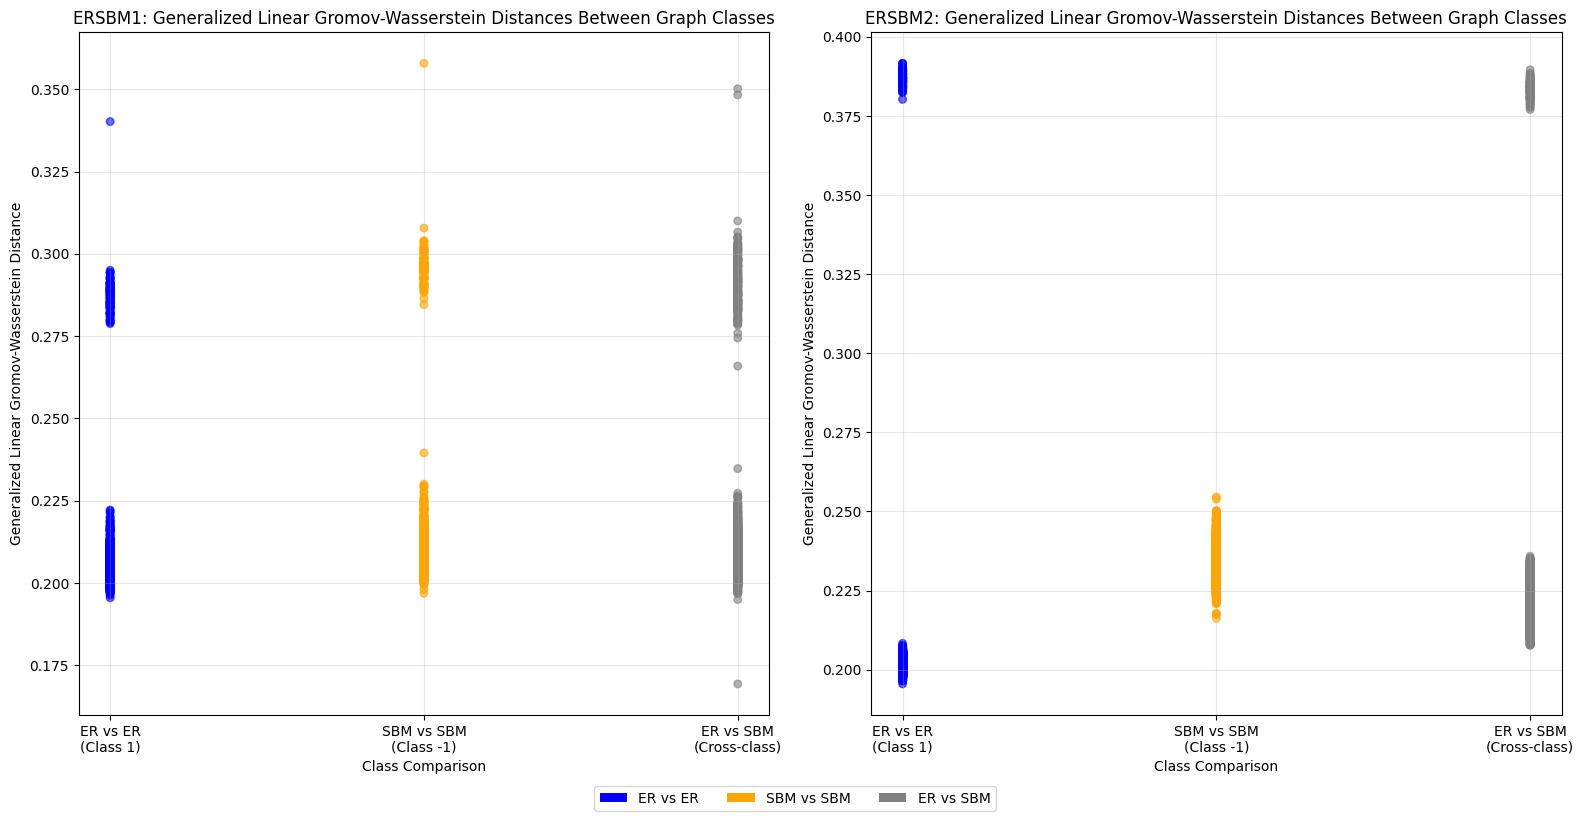

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Analyze ERSBM1 gLGW distances
within_class1_lgw_dist1, within_class_minus1_lgw_dist1, between_classes_lgw_dist1 = analyze_lgw_distances(
    lgw1, labels_array, ax1, 'ERSBM1: Generalized Linear Gromov-Wasserstein Distances Between Graph Classes'
)

# Analyze ERSBM2 gLGW distances
within_class1_lgw_dist2, within_class_minus1_lgw_dist2, between_classes_lgw_dist2 = analyze_lgw_distances(
    lgw5, labels5_array, ax2, 'ERSBM2: Generalized Linear Gromov-Wasserstein Distances Between Graph Classes'
)

# Add legend to the figure
legend_elements = [Patch(facecolor='blue', label='ER vs ER'),
                   Patch(facecolor='orange', label='SBM vs SBM'),
                   Patch(facecolor='gray', label='ER vs SBM')]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)

# Print statistics for both datasets
print("="*60)
print("ERSBM1 gLGW Statistics:")
print(f"Within ER class - Mean: {np.mean(within_class1_lgw_dist1):.4f}, Std: {np.std(within_class1_lgw_dist1):.4f}")
print(f"Within SBM class - Mean: {np.mean(within_class_minus1_lgw_dist1):.4f}, Std: {np.std(within_class_minus1_lgw_dist1):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_lgw_dist1):.4f}, Std: {np.std(between_classes_lgw_dist1):.4f}")

print("\nERSBM2 gLGW Statistics:")
print(f"Within ER class - Mean: {np.mean(within_class1_lgw_dist2):.4f}, Std: {np.std(within_class1_lgw_dist2):.4f}")
print(f"Within SBM class - Mean: {np.mean(within_class_minus1_lgw_dist2):.4f}, Std: {np.std(within_class_minus1_lgw_dist2):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_lgw_dist2):.4f}, Std: {np.std(between_classes_lgw_dist2):.4f}")
print("="*60)

plt.show()

In [15]:
# Perform statistical tests for both ERSBM1 and ERSBM2 gLGW distances
def perform_lgw_statistical_analysis(within_class1_dist, within_class_minus1_dist, between_classes_dist, 
                                    labels_array, dataset_name):
    """Perform statistical analysis on gLGW distances for a dataset"""
    
    # Calculate means
    active_vs_inactive_mean = np.mean(between_classes_dist)
    within_active_mean = np.mean(within_class1_dist)
    within_inactive_mean = np.mean(within_class_minus1_dist)
    
    # Get class indices for counting
    class_1_indices = np.where(labels_array == 1)[0]
    class_minus1_indices = np.where(labels_array == -1)[0]
    
    print(f"\n{dataset_name} gLGW Statistical Summary:")
    print(f"Number of ER graphs: {len(class_1_indices)}")
    print(f"Number of SBM graphs: {len(class_minus1_indices)}")
    print(f"Number of within-ER comparisons: {len(within_class1_dist)}")
    print(f"Number of within-SBM comparisons: {len(within_class_minus1_dist)}")
    print(f"Number of cross-class comparisons: {len(between_classes_dist)}")
    
    # Test if between-class gLGW distances are significantly different from within-class distances
    all_within_class = within_class1_dist + within_class_minus1_dist
    t_stat, p_value = ttest_ind(between_classes_dist, all_within_class)
    print(f"\nT-test for {dataset_name} gLGW (Between-class vs Within-class distances):")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Additional comparison results
    print(f"{dataset_name} gLGW between-class mean: {active_vs_inactive_mean:.4f}")
    print(f"{dataset_name} gLGW within-ER mean: {within_active_mean:.4f}")
    print(f"{dataset_name} gLGW within-SBM mean: {within_inactive_mean:.4f}")
    
    return t_stat, p_value

In [16]:
# Perform statistical analysis for ERSBM1 gLGW
t_stat_lgw1, p_value_lgw1 = perform_lgw_statistical_analysis(
    within_class1_lgw_dist1, within_class_minus1_lgw_dist1, between_classes_lgw_dist1, 
    labels_array, "ERSBM1"
)

# Perform statistical analysis for ERSBM2 gLGW
t_stat_lgw2, p_value_lgw2 = perform_lgw_statistical_analysis(
    within_class1_lgw_dist2, within_class_minus1_lgw_dist2, between_classes_lgw_dist2, 
    labels5_array, "ERSBM2"
)

# Compare the two datasets for gLGW
print(f"\n" + "="*60)
print("gLGW Comparison between ERSBM1 and ERSBM2:")
print(f"ERSBM1 gLGW T-statistic: {t_stat_lgw1:.4f}, P-value: {p_value_lgw1:.4f}")
print(f"ERSBM2 gLGW T-statistic: {t_stat_lgw2:.4f}, P-value: {p_value_lgw2:.4f}")
print(f"Both datasets show significant differences: {'Yes' if (p_value_lgw1 < 0.05 and p_value_lgw2 < 0.05) else 'No'}")


ERSBM1 gLGW Statistical Summary:
Number of ER graphs: 100
Number of SBM graphs: 100
Number of within-ER comparisons: 4950
Number of within-SBM comparisons: 4950
Number of cross-class comparisons: 10000

T-test for ERSBM1 gLGW (Between-class vs Within-class distances):
T-statistic: 0.3479
P-value: 0.7279
Significant difference: No
ERSBM1 gLGW between-class mean: 0.2091
ERSBM1 gLGW within-ER mean: 0.2071
ERSBM1 gLGW within-SBM mean: 0.2109

ERSBM2 gLGW Statistical Summary:
Number of ER graphs: 100
Number of SBM graphs: 100
Number of within-ER comparisons: 4950
Number of within-SBM comparisons: 4950
Number of cross-class comparisons: 10000

T-test for ERSBM2 gLGW (Between-class vs Within-class distances):
T-statistic: 6.7836
P-value: 0.0000
Significant difference: Yes
ERSBM2 gLGW between-class mean: 0.2217
ERSBM2 gLGW within-ER mean: 0.2055
ERSBM2 gLGW within-SBM mean: 0.2340

gLGW Comparison between ERSBM1 and ERSBM2:
ERSBM1 gLGW T-statistic: 0.3479, P-value: 0.7279
ERSBM2 gLGW T-statis

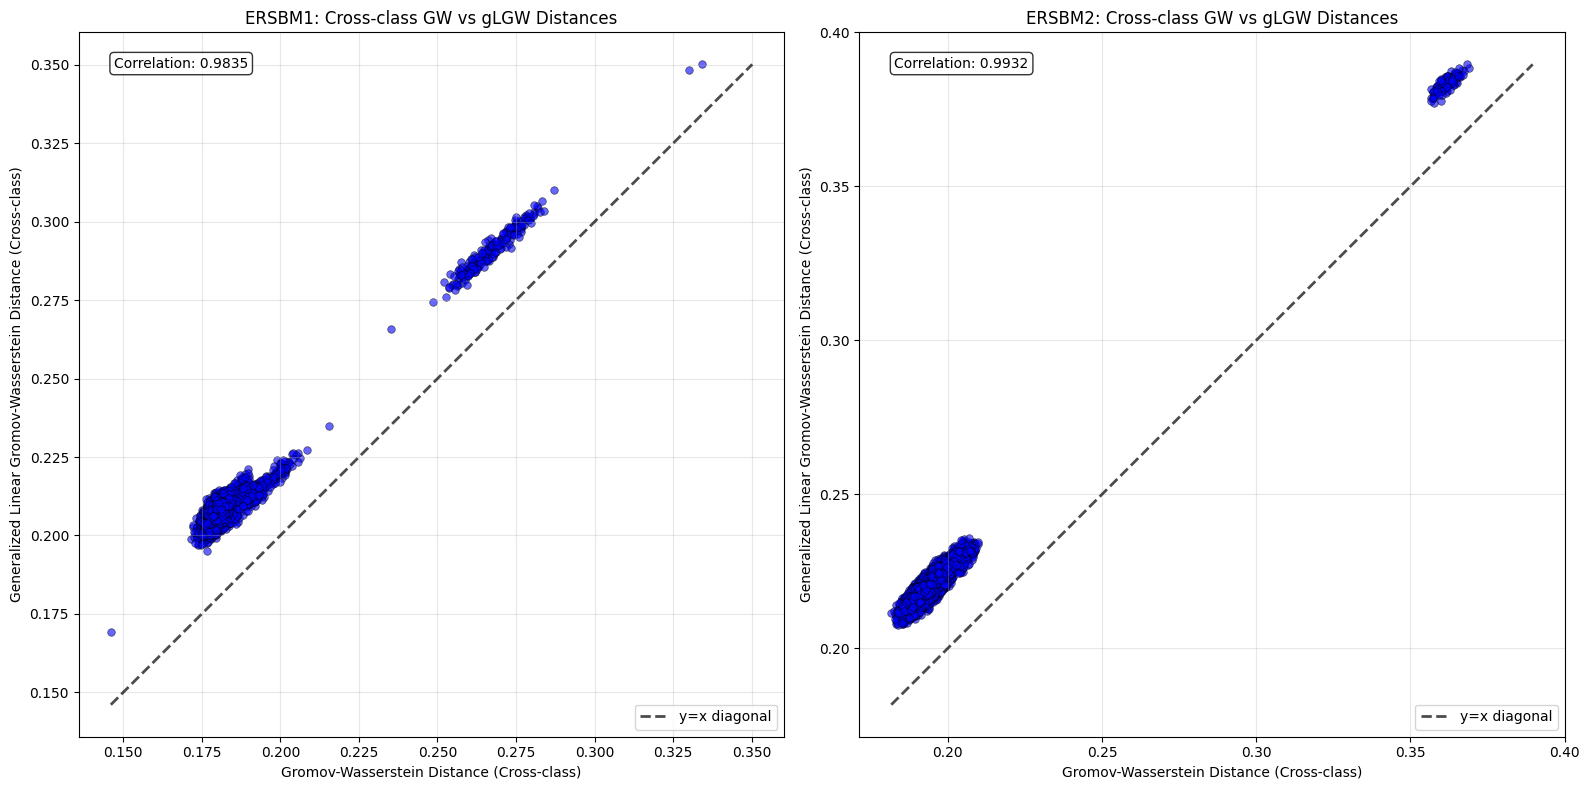

In [17]:
### Scatterplots to compare ERSBM1 GW vs gLGW and ERSBM2 GW vs gLGW
# Create 2D scatterplot comparing cross-class GW vs gLGW distances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


def create_gw_vs_lgw_scatterplot(gw_matrix, lgw_matrix, labels_array, ax,
                                 title):
    """Create a 2D scatterplot comparing cross-class GW vs gLGW distances"""

    # Get indices for each class
    class_1_indices = np.where(labels_array == 1)[0]  # ER class
    class_minus1_indices = np.where(labels_array == -1)[0]  # SBM class

    # Extract cross-class distances only
    gw_cross_class = []
    lgw_cross_class = []

    for i in class_1_indices:
        for j in class_minus1_indices:
            gw_cross_class.append(gw_matrix[i, j])
            lgw_cross_class.append(lgw_matrix[i, j])

    # Create scatter plot
    ax.scatter(gw_cross_class,
               lgw_cross_class,
               alpha=0.6,
               s=30,
               color='blue',
               edgecolors='black',
               linewidth=0.5)

    # Add diagonal line for comparison
    min_val = min(min(gw_cross_class), min(lgw_cross_class))
    max_val = max(max(gw_cross_class), max(lgw_cross_class))
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--',
            alpha=0.7,
            linewidth=2,
            label='y=x diagonal')

    # Customize the plot
    ax.set_xlabel('Gromov-Wasserstein Distance (Cross-class)')
    ax.set_ylabel(
        'Generalized Linear Gromov-Wasserstein Distance (Cross-class)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Calculate correlation coefficient
    correlation = np.corrcoef(gw_cross_class, lgw_cross_class)[0, 1]
    ax.text(0.05,
            0.95,
            f'Correlation: {correlation:.4f}',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return gw_cross_class, lgw_cross_class, correlation


# Create scatterplots for both datasets
gw_cross_1, lgw_cross_1, corr_1 = create_gw_vs_lgw_scatterplot(
    gw, lgw1, labels_array, ax1, 'ERSBM1: Cross-class GW vs gLGW Distances')

gw_cross_2, lgw_cross_2, corr_2 = create_gw_vs_lgw_scatterplot(
    gw5, lgw5, labels5_array, ax2, 'ERSBM2: Cross-class GW vs gLGW Distances')

plt.tight_layout()

In [18]:
# Print correlation statistics
print("\n" + "=" * 60)
print("Cross-class Distance Correlation Analysis:")
print(f"ERSBM1 - GW vs gLGW correlation: {corr_1:.4f}")
print(f"ERSBM2 - GW vs gLGW correlation: {corr_2:.4f}")
print(f"Number of cross-class comparisons per dataset: {len(gw_cross_1)}")
print("=" * 60)

plt.show()


Cross-class Distance Correlation Analysis:
ERSBM1 - GW vs gLGW correlation: 0.9835
ERSBM2 - GW vs gLGW correlation: 0.9932
Number of cross-class comparisons per dataset: 10000



Within-class Distance Correlation Analysis:
ERSBM1 - ER class GW vs gLGW correlation: 0.9844
ERSBM1 - SBM class GW vs gLGW correlation: 0.9821
ERSBM2 - ER class GW vs gLGW correlation: 0.9973
ERSBM2 - SBM class GW vs gLGW correlation: 0.1015
Number of within-ER comparisons (ERSBM1): 4950
Number of within-SBM comparisons (ERSBM1): 4950
Number of within-ER comparisons (ERSBM2): 4950
Number of within-SBM comparisons (ERSBM2): 4950


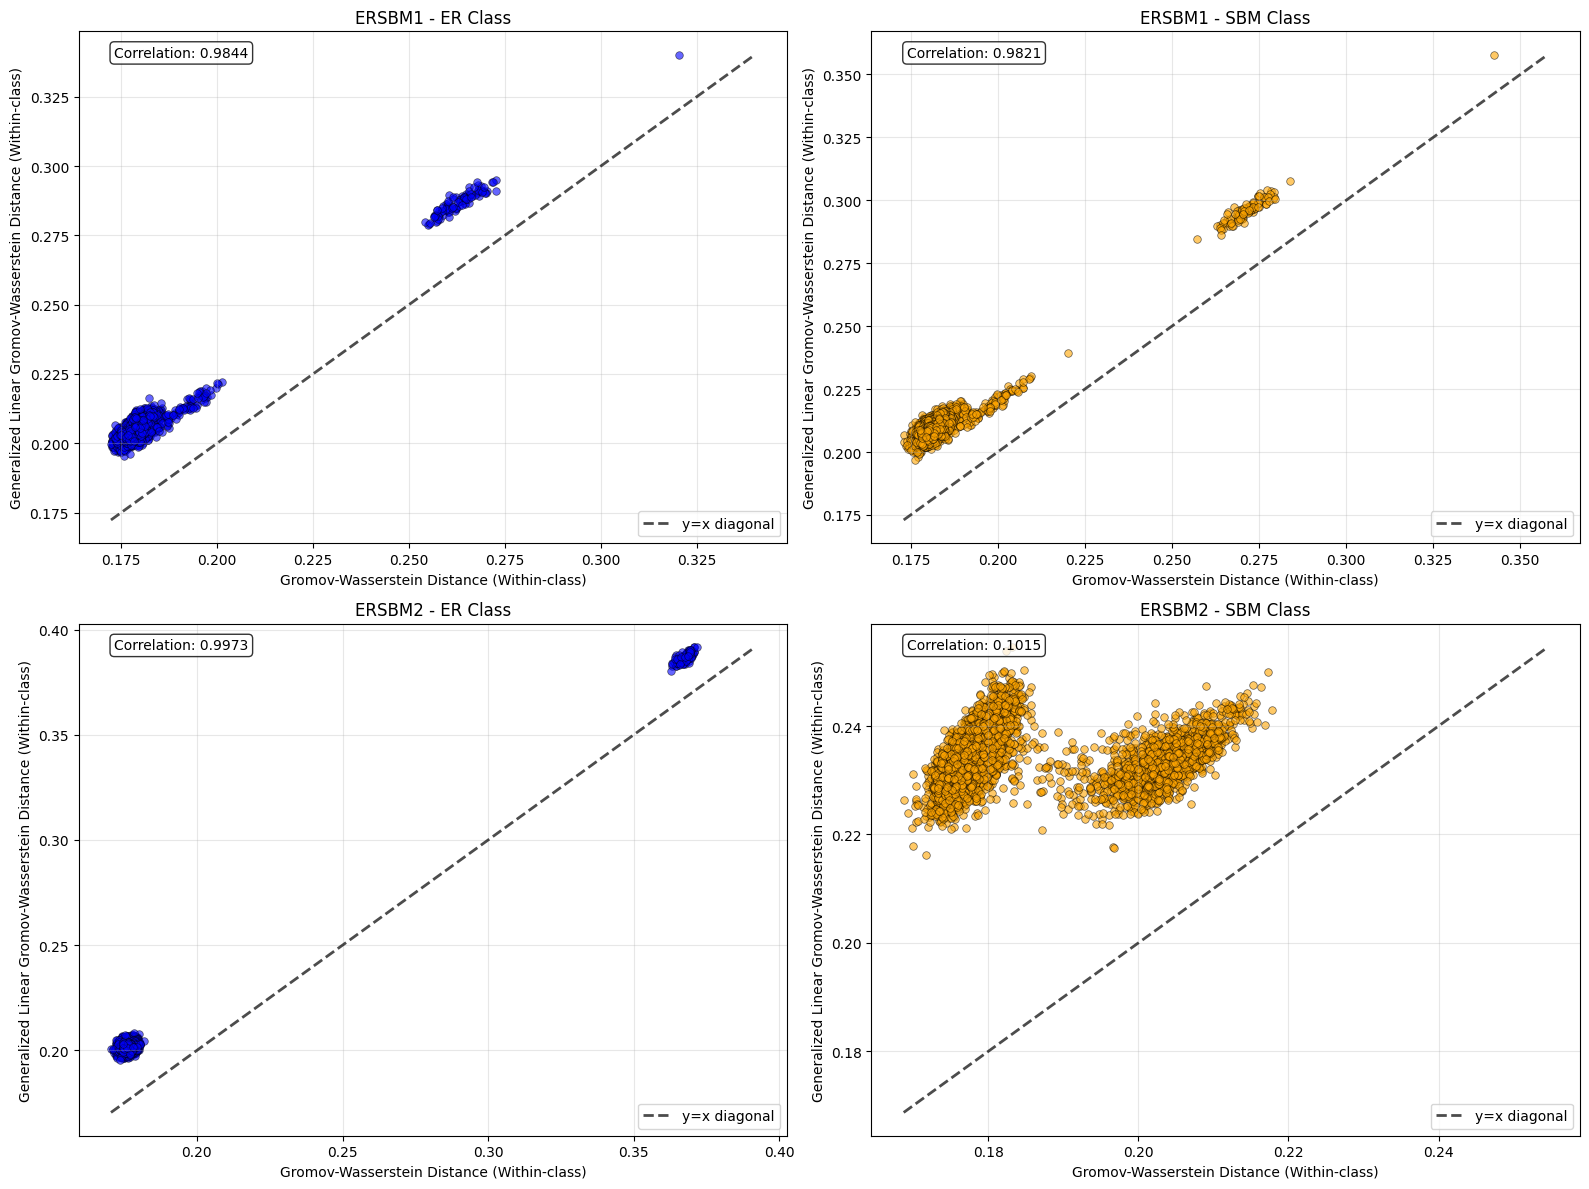

In [19]:
# Creating within-class GW vs gLGW scatterplot comparison
# Create 2D scatterplot comparing within-class GW vs gLGW distances
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

def create_within_class_gw_vs_lgw_scatterplot(gw_matrix, lgw_matrix, labels_array, ax, title, class_label):
    """Create a 2D scatterplot comparing within-class GW vs gLGW distances for a specific class"""

    # Get indices for the specific class
    if class_label == 1:
        class_indices = np.where(labels_array == 1)[0]  # ER class
        class_name = "ER"
        color = 'blue'
    else:
        class_indices = np.where(labels_array == -1)[0]  # SBM class
        class_name = "SBM"
        color = 'orange'

    # Extract within-class distances only
    gw_within_class = []
    lgw_within_class = []

    for i in range(len(class_indices)):
        for j in range(i + 1, len(class_indices)):
            idx_i, idx_j = class_indices[i], class_indices[j]
            gw_within_class.append(gw_matrix[idx_i, idx_j])
            lgw_within_class.append(lgw_matrix[idx_i, idx_j])

    # Create scatter plot
    ax.scatter(gw_within_class, lgw_within_class, alpha=0.6, s=30, color=color, 
               edgecolors='black', linewidth=0.5)

    # Add diagonal line for comparison
    if len(gw_within_class) > 0:
        min_val = min(min(gw_within_class), min(lgw_within_class))
        max_val = max(max(gw_within_class), max(lgw_within_class))
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='y=x diagonal')

    # Customize the plot
    ax.set_xlabel('Gromov-Wasserstein Distance (Within-class)')
    ax.set_ylabel('Generalized Linear Gromov-Wasserstein Distance (Within-class)')
    ax.set_title(f'{title} - {class_name} Class')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Calculate correlation coefficient if there are enough points
    if len(gw_within_class) > 1:
        correlation = np.corrcoef(gw_within_class, lgw_within_class)[0, 1]
        ax.text(0.05, 0.95, f'Correlation: {correlation:.4f}', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        correlation = np.nan
        ax.text(0.05, 0.95, 'Insufficient data', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return gw_within_class, lgw_within_class, correlation

# Create scatterplots for both datasets and both classes
gw_within_active_1, lgw_within_active_1, corr_active_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw1, labels_array, ax1, 'ERSBM1', 1
)

gw_within_inactive_1, lgw_within_inactive_1, corr_inactive_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw1, labels_array, ax2, 'ERSBM1', -1
)

gw_within_active_2, lgw_within_active_2, corr_active_2 = create_within_class_gw_vs_lgw_scatterplot(
    gw5, lgw5, labels5_array, ax3, 'ERSBM2', 1
)

gw_within_inactive_2, lgw_within_inactive_2, corr_inactive_2 = create_within_class_gw_vs_lgw_scatterplot(
    gw5, lgw5, labels5_array, ax4, 'ERSBM2', -1
)

plt.tight_layout()

# Print correlation statistics
print("\n" + "="*60)
print("Within-class Distance Correlation Analysis:")
print(f"ERSBM1 - ER class GW vs gLGW correlation: {corr_active_1:.4f}")
print(f"ERSBM1 - SBM class GW vs gLGW correlation: {corr_inactive_1:.4f}")
print(f"ERSBM2 - ER class GW vs gLGW correlation: {corr_active_2:.4f}")
print(f"ERSBM2 - SBM class GW vs gLGW correlation: {corr_inactive_2:.4f}")
print(f"Number of within-ER comparisons (ERSBM1): {len(gw_within_active_1)}")
print(f"Number of within-SBM comparisons (ERSBM1): {len(gw_within_inactive_1)}")
print(f"Number of within-ER comparisons (ERSBM2): {len(gw_within_active_2)}")
print(f"Number of within-SBM comparisons (ERSBM2): {len(gw_within_inactive_2)}")
print("="*60)

plt.show()

In [20]:
### Distances Scatterplots: Distances from GW Barycenters of Each Class ###
# Compute the GW barycenter for each category: ERSBM1
num_nodes = 100
seed = 42
X_class1 = [
           distance_matrices[j] for j in range(len(distance_matrices)) if labels[j] == -1
        ]
X_class2 = [
            distance_matrices[j] for j in range(len(distance_matrices)) if labels[j] == 1
        ]
barycenter_matrix_class1 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class1,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 1 graphs:",
          barycenter_matrix_class1)
print("GW barycenter for Class 1 graphs computed")
barycenter_matrix_class2 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class2,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 2 graphs:",
          barycenter_matrix_class2)
print("GW barycenter for Class 2 graphs computed")

GW barycenter for Class 1 graphs: [[0.   2.37 1.92 ... 2.02 2.07 2.16]
 [2.37 0.   2.1  ... 2.31 2.35 2.43]
 [1.92 2.1  0.   ... 1.84 1.82 2.01]
 ...
 [2.02 2.31 1.84 ... 0.   1.9  2.13]
 [2.07 2.35 1.82 ... 1.9  0.   2.07]
 [2.16 2.43 2.01 ... 2.13 2.07 0.  ]]
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs: [[0.   2.31 1.7  ... 1.84 1.97 2.07]
 [2.31 0.   2.11 ... 2.23 2.26 2.38]
 [1.7  2.11 0.   ... 1.85 1.85 1.95]
 ...
 [1.84 2.23 1.85 ... 0.   1.96 1.99]
 [1.97 2.26 1.85 ... 1.96 0.   2.05]
 [2.07 2.38 1.95 ... 1.99 2.05 0.  ]]
GW barycenter for Class 2 graphs computed


In [21]:
# Compute the GW barycenter for each category: ERSBM2
X_class1_ERSBM2 = [
           distance_matrices5[j] for j in range(len(distance_matrices5)) if labels5[j] == -1
        ]
X_class2_ERSBM2 = [
            distance_matrices5[j] for j in range(len(distance_matrices5)) if labels5[j] == 1
        ]
barycenter_matrix_class1_ERSBM2 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class1_ERSBM2,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 1 graphs:",
          barycenter_matrix_class1)
print("GW barycenter for Class 1 graphs computed")
barycenter_matrix_class2_ERSBM2 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class2_ERSBM2,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 2 graphs:",
          barycenter_matrix_class2)
print("GW barycenter for Class 2 graphs computed")

GW barycenter for Class 1 graphs: [[0.   2.37 1.92 ... 2.02 2.07 2.16]
 [2.37 0.   2.1  ... 2.31 2.35 2.43]
 [1.92 2.1  0.   ... 1.84 1.82 2.01]
 ...
 [2.02 2.31 1.84 ... 0.   1.9  2.13]
 [2.07 2.35 1.82 ... 1.9  0.   2.07]
 [2.16 2.43 2.01 ... 2.13 2.07 0.  ]]
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs: [[0.   2.31 1.7  ... 1.84 1.97 2.07]
 [2.31 0.   2.11 ... 2.23 2.26 2.38]
 [1.7  2.11 0.   ... 1.85 1.85 1.95]
 ...
 [1.84 2.23 1.85 ... 0.   1.96 1.99]
 [1.97 2.26 1.85 ... 1.96 0.   2.05]
 [2.07 2.38 1.95 ... 1.99 2.05 0.  ]]
GW barycenter for Class 2 graphs computed


In [22]:
def compute_gromov_wasserstein_distance(adj_matrix1, adj_matrix2):
    """
    Compute the Gromov-Wasserstein distance between two adjacency matrices.
    
    Args:
        adj_matrix1: First adjacency matrix
        adj_matrix2: Second adjacency matrix
    
    Returns:
        The Gromov-Wasserstein distance
    """
    n1, n2 = adj_matrix1.shape[0], adj_matrix2.shape[0]
    
    # Create uniform distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2
    
    # Compute Gromov-Wasserstein distance
    gw_dist = np.abs(ot.gromov.gromov_wasserstein2(adj_matrix1, adj_matrix2, p, q, 'square_loss'))
    
    return np.sqrt(gw_dist)

In [23]:
# Distances from each class to each barycenter - ERSBM1
gw_distances_from_SBM_to_SBMbary = []
gw_distances_from_ER_to_SBMbary = []
gw_distances_from_SBM_to_ERbary = []
gw_distances_from_ER_to_ERbary = []

for j in range(len(distance_matrices)):
    if labels[j] == -1:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_SBM_to_SBMbary.append(dist_negone)
        gw_distances_from_SBM_to_ERbary.append(dist_one)
    else:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_ER_to_SBMbary.append(dist_negone)
        gw_distances_from_ER_to_ERbary.append(dist_one)

In [24]:
# Distances from each class to each barycenter - ERSBM2
gw_distances_from_SBM_to_SBMbary5 = []
gw_distances_from_ER_to_SBMbary5 = []
gw_distances_from_SBM_to_ERbary5 = []
gw_distances_from_ER_to_ERbary5 = []

for j in range(len(distance_matrices5)):
    if labels5[j] == -1:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices5[j], barycenter_matrix_class1_ERSBM2)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices5[j], barycenter_matrix_class2_ERSBM2)
        gw_distances_from_SBM_to_SBMbary5.append(dist_negone)
        gw_distances_from_SBM_to_ERbary5.append(dist_one)
    else:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices5[j], barycenter_matrix_class1_ERSBM2)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices5[j], barycenter_matrix_class2_ERSBM2)
        gw_distances_from_ER_to_SBMbary5.append(dist_negone)
        gw_distances_from_ER_to_ERbary5.append(dist_one)

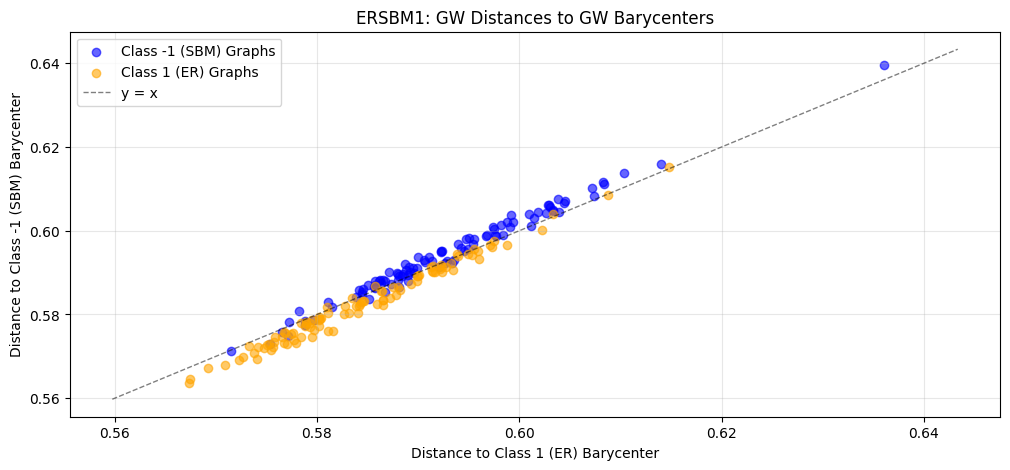

In [25]:
# Plot results - ERSBM1
distances = (gw_distances_from_SBM_to_SBMbary + gw_distances_from_ER_to_SBMbary + 
            gw_distances_from_SBM_to_ERbary + gw_distances_from_ER_to_ERbary)
min_dist = min(distances)
max_dist = max(distances)
margin = (max_dist - min_dist) * 0.05  # Add 5% margin

axis_min = min_dist - margin
axis_max = max_dist + margin

plt.figure(figsize=(12, 5))
plt.scatter(gw_distances_from_SBM_to_SBMbary, gw_distances_from_SBM_to_ERbary, 
           alpha=0.6, label='Class -1 (SBM) Graphs', color='blue')
plt.scatter(gw_distances_from_ER_to_SBMbary, gw_distances_from_ER_to_ERbary, 
           alpha=0.6, label='Class 1 (ER) Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min, axis_max], [axis_min, axis_max],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (ER) Barycenter')
plt.ylabel('Distance to Class -1 (SBM) Barycenter')
plt.title('ERSBM1: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)

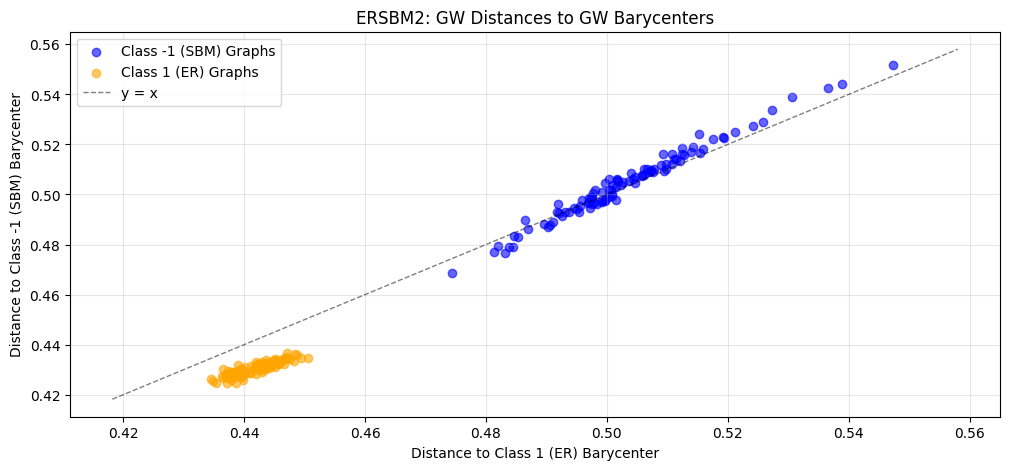

In [26]:
# Plot results - ERSBM2
distances5 = (gw_distances_from_SBM_to_SBMbary5 + gw_distances_from_ER_to_SBMbary5 + 
            gw_distances_from_SBM_to_ERbary5 + gw_distances_from_ER_to_ERbary5)
min_dist5 = min(distances5)
max_dist5 = max(distances5)
margin5 = (max_dist5 - min_dist5) * 0.05  # Add 5% margin

axis_min5 = min_dist5 - margin5
axis_max5 = max_dist5 + margin5

plt.figure(figsize=(12, 5))
plt.scatter(gw_distances_from_SBM_to_SBMbary5, gw_distances_from_SBM_to_ERbary5, 
           alpha=0.6, label='Class -1 (SBM) Graphs', color='blue')
plt.scatter(gw_distances_from_ER_to_SBMbary5, gw_distances_from_ER_to_ERbary5, 
           alpha=0.6, label='Class 1 (ER) Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min5, axis_max5], [axis_min5, axis_max5],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (ER) Barycenter')
plt.ylabel('Distance to Class -1 (SBM) Barycenter')
plt.title('ERSBM2: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)

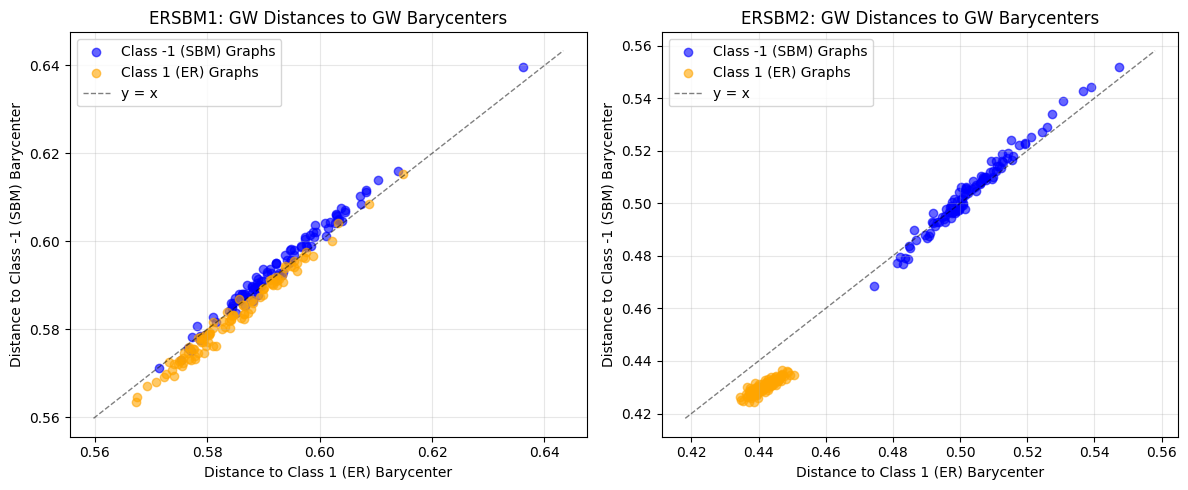

In [27]:
# Put the two plots together: ERSBM1 and ERSBM2
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# ERSBM1
plt.scatter(gw_distances_from_SBM_to_SBMbary, gw_distances_from_SBM_to_ERbary, 
           alpha=0.6, label='Class -1 (SBM) Graphs', color='blue')
plt.scatter(gw_distances_from_ER_to_SBMbary, gw_distances_from_ER_to_ERbary, 
           alpha=0.6, label='Class 1 (ER) Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min, axis_max], [axis_min, axis_max],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (ER) Barycenter')
plt.ylabel('Distance to Class -1 (SBM) Barycenter')
plt.title('ERSBM1: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)
# ERSBM2
plt.subplot(1, 2, 2)
plt.scatter(gw_distances_from_SBM_to_SBMbary5, gw_distances_from_SBM_to_ERbary5, 
           alpha=0.6, label='Class -1 (SBM) Graphs', color='blue')
plt.scatter(gw_distances_from_ER_to_SBMbary5, gw_distances_from_ER_to_ERbary5, 
           alpha=0.6, label='Class 1 (ER) Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min5, axis_max5], [axis_min5, axis_max5],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (ER) Barycenter')
plt.ylabel('Distance to Class -1 (SBM) Barycenter')
plt.title('ERSBM2: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()